# Lab 6: Linear Regression & Gradient Descent Visualization
## Synthetic Dataset: Ohm's Law (1 kΩ Resistor)

### Overview  
In this lab, we will use a **synthetic dataset** based on **Ohm's Law**:

\[
V = IR
\]

Where:  
- \( I \) = current (in Amperes)  
- \( R = 1000 \Omega \) (1 kΩ resistor)  
- \( V \) = voltage (in Volts)

We will:  
✔ Generate synthetic data  
✔ Fit a Linear Regression model (sklearn)  
✔ Plot the regression line  
✔ Visualize gradient descent loss curve  
✔ Compute MAE, RMSE



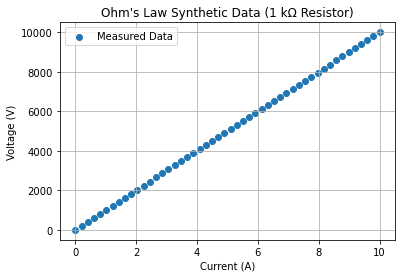

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set true resistance
R_true = 1000  # ohms

# Generate synthetic current (I) between 0 and 10 mA
I = np.linspace(0, 10, 50)  # Amperes

# Generate voltage using Ohm's Law: V = IR
V = R_true * I

# Add small measurement noise
noise = np.random.normal(0, 0.02, size=I.shape)
V_noisy = V + noise

I = I.reshape(-1, 1)

plt.scatter(I, V_noisy, label="Measured Data")
plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Ohm's Law Synthetic Data (1 kΩ Resistor)")
plt.grid(True)
plt.legend()
plt.show()

In [3]:
I_test = np.linspace(0, 0.02, 5)  # Amperes
I_test = I_test.reshape(-1, 1)

v_test= R_true * I_test
noise_test = np.random.normal(0, 0.02, size=I_test.shape)
v_test = v_test + noise_test

In [4]:
# Fit Linear Regression
# model.fit() solves the linear regression equations using 
# matrix algebra (Normal Equation) to directly compute the optimal slope and intercept without using gradient descent.
model = LinearRegression()
model.fit(I, V_noisy)



LinearRegression()

In [5]:
print("slope, m",model.coef_ )  # slope (m)
print("intercept, b",model.intercept_ )   # intercept (b)

slope, m [999.99937103]
intercept, b -0.0011866230242958409


In [6]:
V_pred = model.predict(I_test)

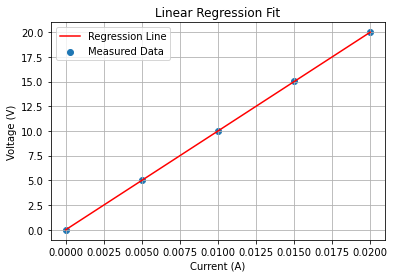

Estimated Resistance (slope): 999.9993710330294
Intercept: -0.0011866230242958409


In [7]:


plt.scatter(I_test, v_test, label="Measured Data")
plt.plot(I_test, V_pred, color="red", label="Regression Line")
plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Linear Regression Fit")
plt.grid(True)
plt.legend()
plt.show()

print("Estimated Resistance (slope):", model.coef_[0])
print("Intercept:", model.intercept_)

In [8]:
# Compute metrics
MAE = mean_absolute_error(v_test, V_pred)
RMSE = np.sqrt(mean_squared_error(v_test, V_pred))

print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 0.017963009128814888
RMSE: 0.027723692875770214
